# Emergency Response Time Prediction

***This notebook predicts emergency response time using machine learning models.  
It compares CatBoost, XGBoost, and Quantile Random Forest using quantile regression.***

The goal is not only to predict the median response time, but also to estimate uncertainty using Q10 and Q90 prediction intervals.

In [1]:
###Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_pinball_loss
)

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor

In [2]:
###Load the dataset
df = pd.read_csv("emergency_service_routing_with_timestamps.csv")

df.head()

,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,...,Specialist_Availability,Road_Type,Emergency_Level,Drone_Speed,Ambulance_Speed,Payload_Weight,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Label
0,2018-01-01 00:00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,Available,71.177951,Low,...,Unavailable,Highway,Major,59.578538,43.549849,9.28,90.030756,Severe,AI,Ambulance Only
1,2018-01-01 00:10:00,Low,Other,Urban,Moderate,Clear,Available,Available,70.949595,Low,...,Unavailable,Highway,Critical,74.578440,30.687975,9.47,88.255008,Moderate,Human,Ambulance Only
2,2018-01-01 00:20:00,Medium,Cardiac Arrest,Suburban,High,Rainy,Unavailable,Available,74.346037,Medium,...,Unavailable,Unpaved Road,Minor,45.900425,44.456331,8.77,97.719622,NaN,Human,Hybrid Dispatch
3,2018-01-01 00:30:00,Low,Accident,Urban,Moderate,Clear,Available,Available,84.199630,Medium,...,Available,Highway,Minor,50.927769,35.879968,4.76,60.234672,NaN,Human,Ambulance Only
4,2018-01-01 00:40:00,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,Available,78.492584,Low,...,Available,Highway,Minor,71.312741,26.369383,3.83,71.083564,Moderate,Human,Ambulance Only


In [3]:
###Check the dataset structure and missing values
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368065 entries, 0 to 368064
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Timestamp                368065 non-null  object 
 1   Incident_Severity        368065 non-null  object 
 2   Incident_Type            368065 non-null  object 
 3   Region_Type              368065 non-null  object 
 4   Traffic_Congestion       368065 non-null  object 
 5   Weather_Condition        368065 non-null  object 
 6   Drone_Availability       368065 non-null  object 
 7   Ambulance_Availability   368065 non-null  object 
 8   Battery_Life             368065 non-null  float64
 9   Air_Traffic              368065 non-null  object 
 10  Response_Time            368065 non-null  float64
 11  Hospital_Capacity        368065 non-null  int64  
 12  Distance_to_Incident     368065 non-null  float64
 13  Number_of_Injuries       368065 non-null  int64  
 14  Spec

In [4]:
df["Response_Time"] = pd.to_numeric(df["Response_Time"], errors="coerce")
timestamp_cols = [
    col for col in df.columns
    if ("timestamp" in col.lower() or "date" in col.lower())
    and col != "Response_Time"
]

for col in timestamp_cols:
    try:
        df[col] = pd.to_datetime(df[col])
    except:
        pass

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368065 entries, 0 to 368064
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Timestamp                368065 non-null  datetime64[ns]
 1   Incident_Severity        368065 non-null  object        
 2   Incident_Type            368065 non-null  object        
 3   Region_Type              368065 non-null  object        
 4   Traffic_Congestion       368065 non-null  object        
 5   Weather_Condition        368065 non-null  object        
 6   Drone_Availability       368065 non-null  object        
 7   Ambulance_Availability   368065 non-null  object        
 8   Battery_Life             368065 non-null  float64       
 9   Air_Traffic              368065 non-null  object        
 10  Response_Time            368065 non-null  float64       
 11  Hospital_Capacity        368065 non-null  int64         
 12  Distance_to_Inci

In [5]:
##Create ETA features
### ETA = Distance / Speed × 60
df["eta_drone"] = df["Distance_to_Incident"] / df["Drone_Speed"] * 60
df["eta_ambulance"] = df["Distance_to_Incident"] / df["Ambulance_Speed"] * 60

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df[["eta_drone", "eta_ambulance"]].head()

,eta_drone,eta_ambulance
0,8.952888,12.248033
1,22.607070,54.940086
2,52.849184,54.565906
3,22.349300,31.722437
4,13.722653,37.111221


***The previous features are valid if they are before the dispatch decision.***

## Assumptions

All features used for prediction are assumed to be available at dispatch time.

The target variable `Response_Time` is excluded from training to avoid direct leakage.  
The historical dispatch `Label` is also excluded because the goal is to support new dispatch decisions rather than copy past decisions.

In [6]:
###Define target variable
###We also remove Label because it represents a previous decision and could make the model copy old decisions instead of learning response-time patterns.
target = "Response_Time"

drop_cols = [
    "Response_Time",
    "Label"
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

X.head()

,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,...,Road_Type,Emergency_Level,Drone_Speed,Ambulance_Speed,Payload_Weight,Fuel_Level,Weather_Impact,Dispatch_Coordinator,eta_drone,eta_ambulance
0,2018-01-01 00:00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,Available,71.177951,Low,...,Highway,Major,59.578538,43.549849,9.28,90.030756,Severe,AI,8.952888,12.248033
1,2018-01-01 00:10:00,Low,Other,Urban,Moderate,Clear,Available,Available,70.949595,Low,...,Highway,Critical,74.578440,30.687975,9.47,88.255008,Moderate,Human,22.607070,54.940086
2,2018-01-01 00:20:00,Medium,Cardiac Arrest,Suburban,High,Rainy,Unavailable,Available,74.346037,Medium,...,Unpaved Road,Minor,45.900425,44.456331,8.77,97.719622,NaN,Human,52.849184,54.565906
3,2018-01-01 00:30:00,Low,Accident,Urban,Moderate,Clear,Available,Available,84.199630,Medium,...,Highway,Minor,50.927769,35.879968,4.76,60.234672,NaN,Human,22.349300,31.722437
4,2018-01-01 00:40:00,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,Available,78.492584,Low,...,Highway,Minor,71.312741,26.369383,3.83,71.083564,Moderate,Human,13.722653,37.111221


In [7]:
###Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 294452
Testing rows: 73613


In [8]:
# Convert datetime column before encoding
for df in [X_train, X_test]:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

    df["timestamp_year"] = df["Timestamp"].dt.year
    df["timestamp_month"] = df["Timestamp"].dt.month
    df["timestamp_day"] = df["Timestamp"].dt.day
    df["timestamp_dayofweek"] = df["Timestamp"].dt.dayofweek
    df["timestamp_hour"] = df["Timestamp"].dt.hour

    df.drop(columns=["Timestamp"], inplace=True)


In [9]:
###Handle missing values after splitting and encoding
###justification for handling missing values after splitting: This approach prevents data leakage by ensuring that the imputation process is based solely on the training data, which allows the model to learn patterns without being influenced by information from the test set. It also provides a more realistic evaluation of the model's performance on unseen data, as the imputation strategy is applied consistently across both sets.
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")

# Fill numeric missing values
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Fill categorical missing values
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Convert categorical columns to string so CatBoost does not see NaN or mixed object types
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Check that no missing values remain
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


***Encode categorical columns***
Explanation
***Machine learning models like XGBoost and Quantile Random Forest need numeric input.***
So we convert categorical columns into dummy variables using one-hot encoding.

In [10]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (294452, 38)
Encoded testing shape: (73613, 38)


In [11]:
# Force all categorical columns to safe strings
cat_features = list(X_train.select_dtypes(include=["object", "category"]).columns)

for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

# Check categorical columns
X_train[cat_features].isnull().sum()

Incident_Severity          0
Incident_Type              0
Region_Type                0
Traffic_Congestion         0
Weather_Condition          0
Drone_Availability         0
Ambulance_Availability     0
Air_Traffic                0
Specialist_Availability    0
Road_Type                  0
Emergency_Level            0
Weather_Impact             0
Dispatch_Coordinator       0
dtype: int64

In [12]:
###Train CatBoost quantile models
cat_features = list(X_train.select_dtypes(include=["object", "category"]).columns)

catboost_quantile_models = {}

for q in [0.1, 0.5, 0.9]:
    model = CatBoostRegressor(
        loss_function=f"Quantile:alpha={q}",
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0
    )
    
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )
    
    catboost_quantile_models[q] = model

cat_pred_q10 = catboost_quantile_models[0.1].predict(X_test)
cat_pred_q50 = catboost_quantile_models[0.5].predict(X_test)
cat_pred_q90 = catboost_quantile_models[0.9].predict(X_test)

In [13]:
###Train XGBoost quantile models
xgb_quantile_models = {}

for q in [0.1, 0.5, 0.9]:
    model = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
   
    model.fit(X_train_encoded, y_train)
    xgb_quantile_models[q] = model

xgb_pred_q10 = xgb_quantile_models[0.1].predict(X_test_encoded)
xgb_pred_q50 = xgb_quantile_models[0.5].predict(X_test_encoded)
xgb_pred_q90 = xgb_quantile_models[0.9].predict(X_test_encoded)

In [14]:
qrf_model = RandomForestQuantileRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,          # limit tree depth
    min_samples_leaf=5,    #for smoother and faster running as Random Forest is too low with big datasets
    max_features="sqrt",   # fewer features checked per split
    n_jobs=-1,             # use all CPU cores
    
)

qrf_model.fit(X_train_encoded, y_train)

qrf_pred_q10 = qrf_model.predict(X_test_encoded, quantiles=0.1)
qrf_pred_q50 = qrf_model.predict(X_test_encoded, quantiles=0.5)
qrf_pred_q90 = qrf_model.predict(X_test_encoded, quantiles=0.9)

In [15]:
####Evaluation function for quantile regression models
def evaluate_quantile_model(name, y_true, q10, q50, q90):
    return {
        "Model": name,
        "R2": r2_score(y_true, q50),
        "RMSE": np.sqrt(mean_squared_error(y_true, q50)),
        "MAE": mean_absolute_error(y_true, q50),
        "Pinball Q10": mean_pinball_loss(y_true, q10, alpha=0.1),
        "Pinball Q50": mean_pinball_loss(y_true, q50, alpha=0.5),
        "Pinball Q90": mean_pinball_loss(y_true, q90, alpha=0.9),
        "Q90 Coverage": (y_true <= q90).mean(),
        "Q10-Q90 Coverage": ((y_true >= q10) & (y_true <= q90)).mean(),
        "Average Interval Width": np.mean(q90 - q10)
    }

In [16]:
baseline_q10 = np.full_like(y_test, y_train.quantile(0.1), dtype=float)
baseline_q50 = np.full_like(y_test, y_train.quantile(0.5), dtype=float)
baseline_q90 = np.full_like(y_test, y_train.quantile(0.9), dtype=float)

In [17]:
results = []

results.append(
    evaluate_quantile_model(
        "Median / Empirical Quantile Baseline",
        y_test,
        baseline_q10,
        baseline_q50,
        baseline_q90
    )
)

results.append(
    evaluate_quantile_model(
        "CatBoost",
        y_test,
        cat_pred_q10,
        cat_pred_q50,
        cat_pred_q90
    )
)

results.append(
    evaluate_quantile_model(
        "XGBoost",
        y_test,
        xgb_pred_q10,
        xgb_pred_q50,
        xgb_pred_q90
    )
)

results.append(
    evaluate_quantile_model(
        "Quantile Random Forest",
        y_test,
        qrf_pred_q10,
        qrf_pred_q50,
        qrf_pred_q90
    )
)

results_df = pd.DataFrame(results)
results_df

,Model,R2,RMSE,MAE,Pinball Q10,Pinball Q50,Pinball Q90,Q90 Coverage,Q10-Q90 Coverage,Average Interval Width
0,Median / Empirical Quantile Baseline,-0.000003,4.893293,3.943918,0.837494,1.971959,0.873681,0.900710,0.799016,12.792225
1,CatBoost,-0.000653,4.894883,3.945394,0.837651,1.972697,0.873846,0.900276,0.797916,12.781096
2,XGBoost,-0.003508,4.901862,3.951180,0.840275,1.975590,0.876690,0.896295,0.790458,12.598418
3,Quantile Random Forest,-0.013623,4.926503,3.968785,0.852606,1.984392,0.887270,0.889340,0.776887,12.380097


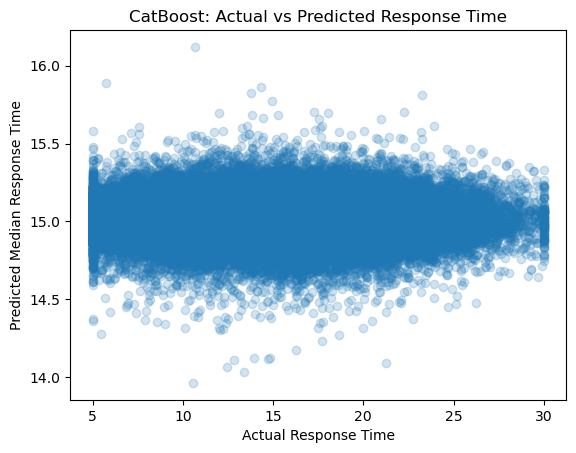

In [18]:
plt.scatter(y_test, cat_pred_q50, alpha=0.2)
plt.xlabel("Actual Response Time")
plt.ylabel("Predicted Median Response Time")
plt.title("CatBoost: Actual vs Predicted Response Time")
plt.show()

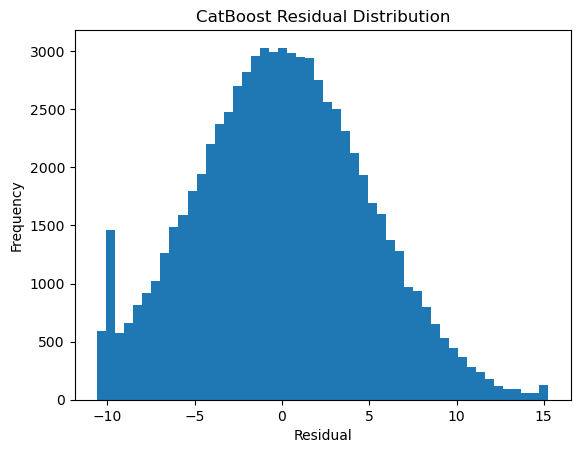

In [19]:
###Residual = Actual - Predicted
residuals = y_test - cat_pred_q50

plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("CatBoost Residual Distribution")
plt.show()

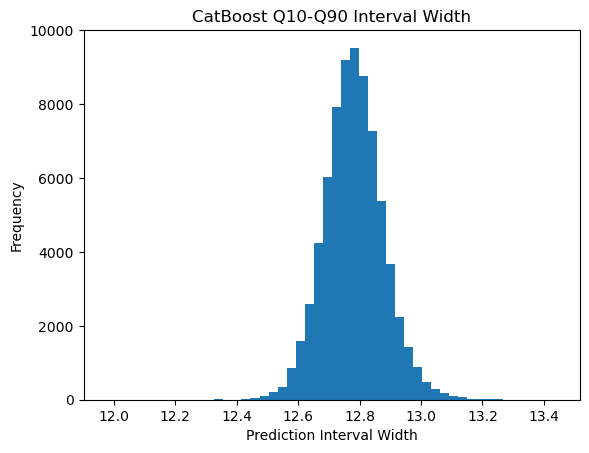

In [20]:
###Plot interval width

interval_width = cat_pred_q90 - cat_pred_q10

plt.hist(interval_width, bins=50)
plt.xlabel("Prediction Interval Width")
plt.ylabel("Frequency")
plt.title("CatBoost Q10-Q90 Interval Width")
plt.show()

## 5.9 Interface and Visualization Realization — Model Comparison Visuals

The cells below extend the visualization that previously existed only for CatBoost (see the Actual vs Predicted, Residual, and Interval Width plots above) to all three trained models, so the three approaches can be compared visually before the final model-selection statement below.

In [21]:
###Reusable visualization functions (applied to all three models)
def plot_actual_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.2)
    plt.xlabel("Actual Response Time")
    plt.ylabel("Predicted Median Response Time (Q50)")
    plt.title(f"{model_name}: Actual vs Predicted Response Time")
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        "r--"
    )
    plt.show()


def plot_residuals(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=50)
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} Residual Distribution")
    plt.show()


def plot_interval_width(q10_pred, q90_pred, model_name):
    interval_width = q90_pred - q10_pred
    plt.figure(figsize=(6, 4))
    plt.hist(interval_width, bins=50)
    plt.xlabel("Q90 - Q10 Interval Width")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} Prediction Interval Width")
    plt.show()

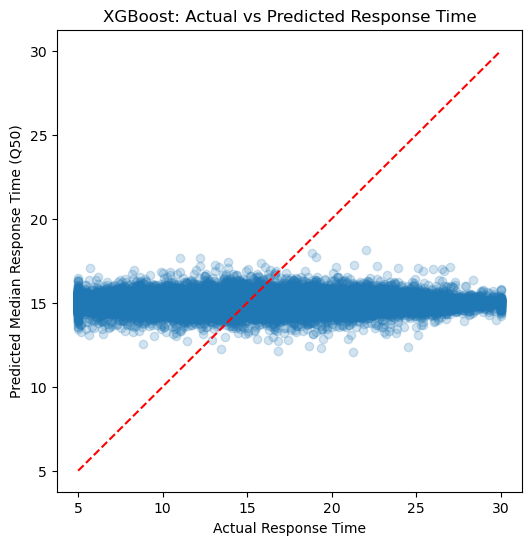

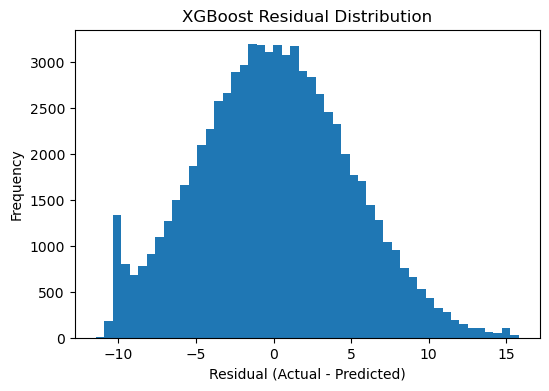

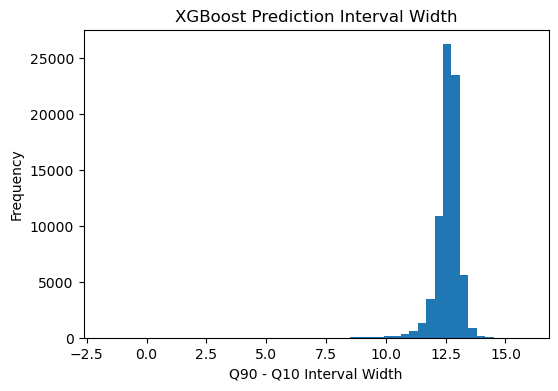

In [22]:
###Visualization for XGBoost
plot_actual_vs_predicted(y_test, xgb_pred_q50, "XGBoost")
plot_residuals(y_test, xgb_pred_q50, "XGBoost")
plot_interval_width(xgb_pred_q10, xgb_pred_q90, "XGBoost")

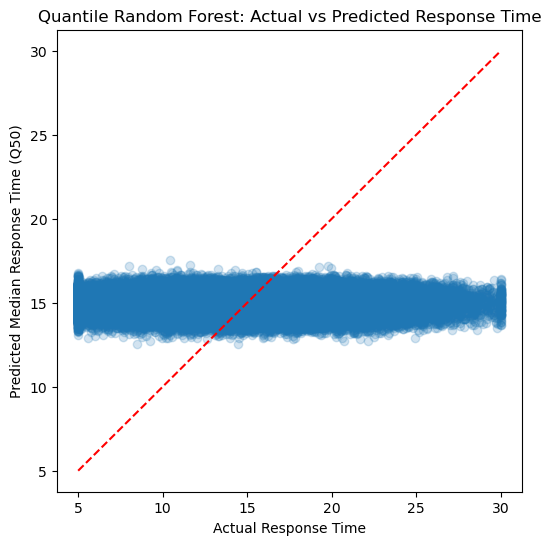

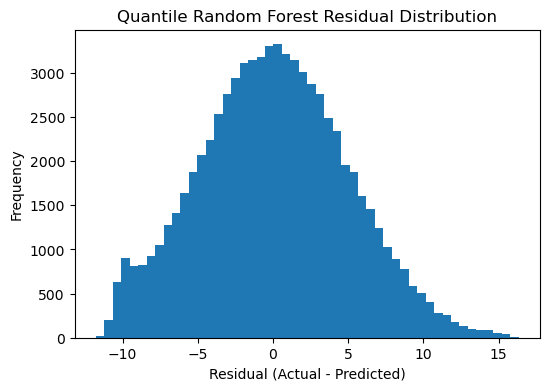

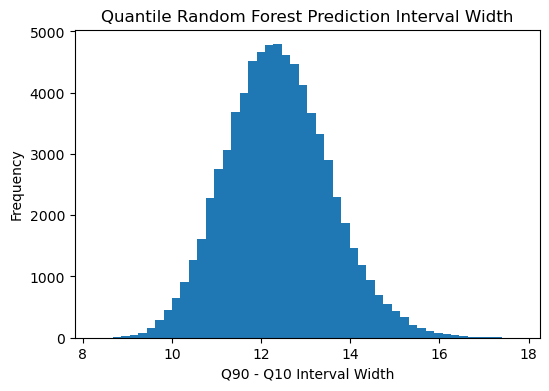

In [23]:
###Visualization for Quantile Random Forest
plot_actual_vs_predicted(y_test, qrf_pred_q50, "Quantile Random Forest")
plot_residuals(y_test, qrf_pred_q50, "Quantile Random Forest")
plot_interval_width(qrf_pred_q10, qrf_pred_q90, "Quantile Random Forest")

C:\Users\msi\AppData\Local\Temp\ipykernel_12752\2849422568.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


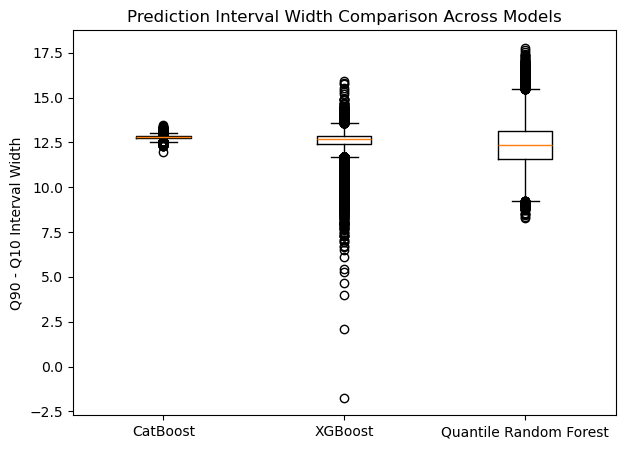

In [24]:
###Side-by-side interval width comparison across all three models
plt.figure(figsize=(7, 5))
plt.boxplot(
    [
        cat_pred_q90 - cat_pred_q10,
        xgb_pred_q90 - xgb_pred_q10,
        qrf_pred_q90 - qrf_pred_q10
    ],
    labels=["CatBoost", "XGBoost", "Quantile Random Forest"]
)
plt.ylabel("Q90 - Q10 Interval Width")
plt.title("Prediction Interval Width Comparison Across Models")
plt.show()

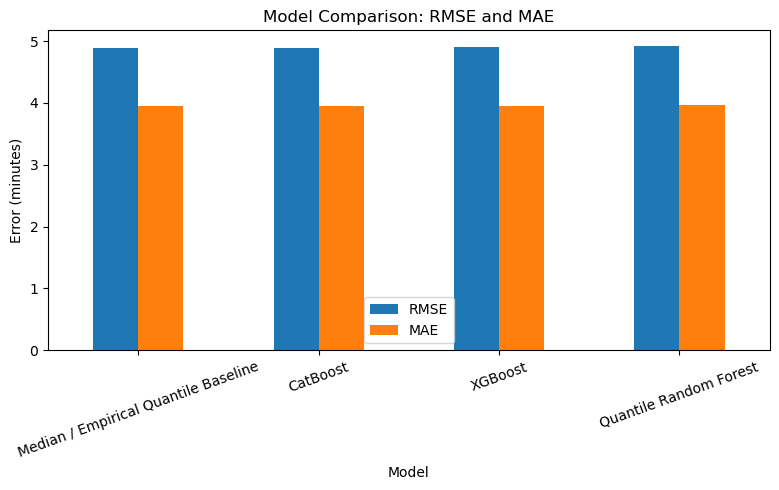

In [25]:
###Bar chart comparison of evaluation metrics from results_df
metrics_to_plot = ["RMSE", "MAE"]

results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar", figsize=(8, 5)
)
plt.ylabel("Error (minutes)")
plt.title("Model Comparison: RMSE and MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [26]:
###Save trained models to disk for later reuse (e.g. by a Flask prediction service)
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

# CatBoost has its own native save format
for q, model in catboost_quantile_models.items():
    model.save_model(f"saved_models/catboost_q{int(q*100)}.cbm")

# XGBoost, Quantile Random Forest, imputers and column schemas are saved with joblib
joblib.dump(xgb_quantile_models, "saved_models/xgb_quantile_models.joblib")
joblib.dump(qrf_model, "saved_models/qrf_model.joblib")
joblib.dump(num_imputer, "saved_models/num_imputer.joblib")
joblib.dump(cat_imputer, "saved_models/cat_imputer.joblib")
joblib.dump(list(numeric_cols), "saved_models/numeric_cols.joblib")
joblib.dump(list(categorical_cols), "saved_models/categorical_cols.joblib")
joblib.dump(list(X_train_encoded.columns), "saved_models/encoded_columns.joblib")
joblib.dump(cat_features, "saved_models/cat_features.joblib")

# IMPORTANT: CatBoost matches categorical features by column POSITION, not name.
# The exact training column order must be saved and reproduced at prediction
# time, or CatBoost will misclassify a numeric column as categorical (or vice
# versa) and raise a CatBoostError.
joblib.dump(list(X_train.columns), "saved_models/catboost_feature_columns.joblib")

print("All models and preprocessing artifacts saved to ./saved_models/")

All models and preprocessing artifacts saved to ./saved_models/


CatBoost was selected as the final model because it produced the best R², RMSE, MAE, and Q50 pinball loss, while maintaining Q10–Q90 coverage close to the nominal 80% level. However, its improvement over the baseline was very small, so the model should be interpreted cautiously.

In [27]:
test_results = X_test.copy()

test_results["actual_response_time"] = y_test.values
test_results["response_q10"] = cat_pred_q10
test_results["response_q50"] = cat_pred_q50
test_results["response_q90"] = cat_pred_q90

test_results.head()

,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,Hospital_Capacity,...,eta_ambulance,timestamp_year,timestamp_month,timestamp_day,timestamp_dayofweek,timestamp_hour,actual_response_time,response_q10,response_q50,response_q90
100398,Low,Accident,Urban,Low,Clear,Unavailable,Available,87.188361,Medium,89.0,...,45.830939,2019,11,29,4,5,12.813874,8.681750,14.910620,21.346388
104224,Low,Cardiac Arrest,Urban,Moderate,Stormy,Unavailable,Available,62.589474,Low,54.0,...,5.036437,2019,12,25,2,18,12.746244,8.542244,15.073944,21.507285
137808,High,Accident,Urban,Moderate,Clear,Available,Available,84.116170,Low,49.0,...,36.237893,2020,8,15,5,0,15.742357,8.727440,15.071496,21.444909
268981,Low,Accident,Urban,High,Clear,Available,Available,83.578719,Low,60.0,...,61.328563,2023,2,11,5,22,24.691979,8.625871,15.048308,21.413247
184905,Low,Accident,Urban,Low,Clear,Unavailable,Available,93.564650,Low,71.0,...,34.553465,2021,7,8,3,1,15.608620,8.550850,14.948108,21.317035


In [28]:
def recommend_dispatch(row):
    critical_case = row["Incident_Severity"] == "High"
    high_response_risk = row["response_q90"] > 15
    drone_available = row["Drone_Availability"] == "Available"
    ambulance_available = row["Ambulance_Availability"] == "Available"

    if high_response_risk and drone_available and ambulance_available:
        return "Hybrid Dispatch"
    elif critical_case and ambulance_available:
        return "Ambulance Dispatch"
    elif drone_available:
        return "Drone Dispatch"
    else:
        return "Delayed / Manual Review"

In [29]:
test_results["recommended_dispatch"] = test_results.apply(
    recommend_dispatch,
    axis=1
)

test_results[
    [
        "Incident_Severity",
        "Incident_Type",
        "Drone_Availability",
        "Ambulance_Availability",
        "actual_response_time",
        "response_q10",
        "response_q50",
        "response_q90",
        "recommended_dispatch"
    ]
].head(20)

,Incident_Severity,Incident_Type,Drone_Availability,Ambulance_Availability,actual_response_time,response_q10,response_q50,response_q90,recommended_dispatch
100398,Low,Accident,Unavailable,Available,12.813874,8.681750,14.910620,21.346388,Delayed / Manual Review
104224,Low,Cardiac Arrest,Unavailable,Available,12.746244,8.542244,15.073944,21.507285,Delayed / Manual Review
137808,High,Accident,Available,Available,15.742357,8.727440,15.071496,21.444909,Hybrid Dispatch
268981,Low,Accident,Available,Available,24.691979,8.625871,15.048308,21.413247,Hybrid Dispatch
184905,Low,Accident,Unavailable,Available,15.608620,8.550850,14.948108,21.317035,Delayed / Manual Review
202867,Low,Other,Unavailable,Available,18.619901,8.603819,14.814045,21.450755,Delayed / Manual Review
248188,Low,Accident,Available,Available,8.705036,8.610276,14.892342,21.343662,Hybrid Dispatch
86659,High,Accident,Available,Available,13.450929,8.718564,15.145389,21.547254,Hybrid Dispatch
254854,Low,Accident,Available,Available,21.196182,8.696682,15.062928,21.434479,Hybrid Dispatch
26407,Low,Fire,Available,Available,22.634140,8.671997,15.100295,21.362747,Hybrid Dispatch


## Conclusion

This notebook developed a quantile regression approach for emergency response time prediction. CatBoost, XGBoost, and Quantile Random Forest were compared against an empirical quantile baseline.

CatBoost produced the best overall results among the machine learning models. However, its R² value was still negative, meaning the model does not strongly explain variation in response time. The actual-vs-predicted plot shows that predictions are concentrated around the average response time rather than closely following  a realistic response times.

The quantile predictions are still useful for estimating uncertainty. The Q10-Q90 interval gives a lower and upper range for possible response time, and the Q90 value can be used to identify high-risk delayed responses.

The dispatch recommendation system uses incident severity, emergency level, vehicle availability, and predicted Q90 response time. Hybrid dispatch is recommended mainly for high-severity or critical cases with high predicted delay risk.

In [30]:
test_results["recommended_dispatch"].value_counts()

recommended_dispatch
Hybrid Dispatch            46463
Delayed / Manual Review    20071
Drone Dispatch              5122
Ambulance Dispatch          1957
Name: count, dtype: int64

In [31]:
import os
os.listdir("saved_models")


['catboost_feature_columns.joblib',
 'catboost_q10.cbm',
 'catboost_q50.cbm',
 'catboost_q90.cbm',
 'categorical_cols.joblib',
 'cat_features.joblib',
 'cat_imputer.joblib',
 'encoded_columns.joblib',
 'numeric_cols.joblib',
 'num_imputer.joblib',
 'qrf_model.joblib',
 'xgb_quantile_models.joblib']